# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [2]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [3]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


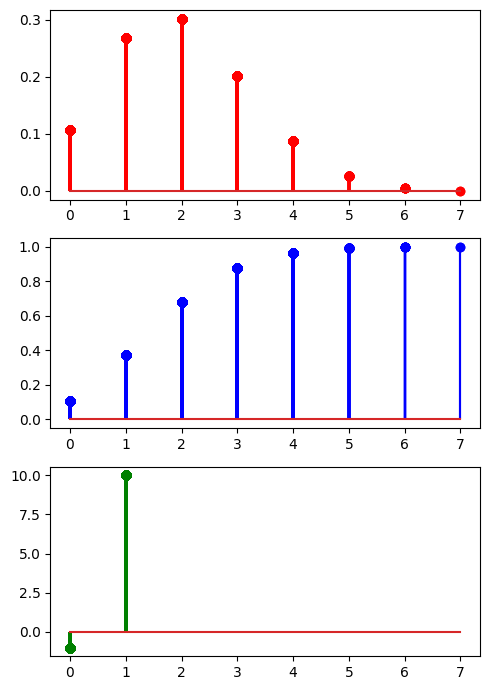

In [4]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

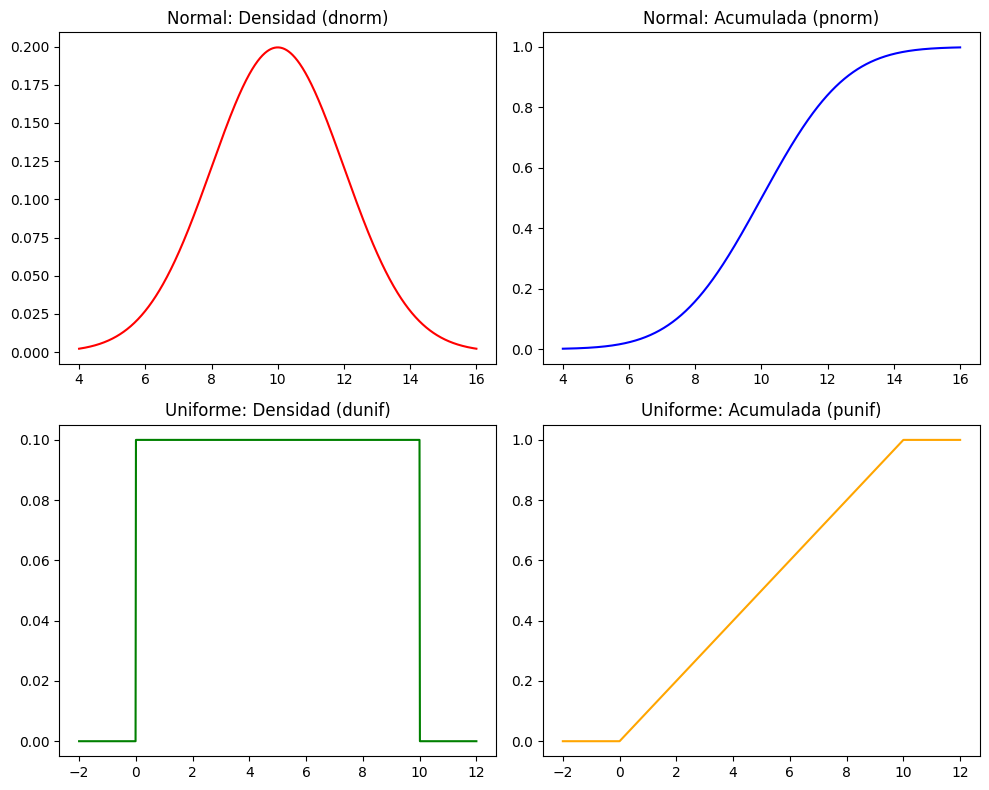

Probabilidad de que un valor normal (10, 2) sea menor a 8: 0.15865525393145707
Generar 5 números aleatorios uniformes (0 a 100): [37.45401188 95.07143064 73.19939418 59.86584842 15.60186404]


In [6]:
# TODO
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform

# ==========================================
# 1. FUNCIONES PARA DISTRIBUCIÓN NORMAL
# ==========================================

def dnorm(x, mean=0, sd=1):
    """Densidad de probabilidad (PDF) de la Normal"""
    return norm.pdf(x, loc=mean, scale=sd)

def pnorm(q, mean=0, sd=1):
    """Probabilidad acumulada (CDF) de la Normal"""
    return norm.cdf(q, loc=mean, scale=sd)

def qnorm(p, mean=0, sd=1):
    """Función cuantil (PPF) de la Normal"""
    return norm.ppf(p, loc=mean, scale=sd)

def rnorm(n, mean=0, sd=1):
    """Generador de números aleatorios (RVS) de la Normal"""
    return norm.rvs(loc=mean, scale=sd, size=n)

# ==========================================
# 2. FUNCIONES PARA DISTRIBUCIÓN UNIFORME
# ==========================================

def dunif(x, start=0, end=1):
    """Densidad de probabilidad (PDF) de la Uniforme"""
    # scale es la diferencia entre el final y el inicio
    return uniform.pdf(x, loc=start, scale=end - start)

def punif(q, start=0, end=1):
    """Probabilidad acumulada (CDF) de la Uniforme"""
    return uniform.cdf(q, loc=start, scale=end - start)

def qunif(p, start=0, end=1):
    """Función cuantil (PPF) de la Uniforme"""
    return uniform.ppf(p, loc=start, scale=end - start)

def runif(n, start=0, end=1):
    """Generador de números aleatorios (RVS) de la Uniforme"""
    return uniform.rvs(loc=start, scale=end - start, size=n)

# ==========================================
# 3. EJECUCIÓN Y VISUALIZACIÓN
# ==========================================

np.random.seed(42)

# Crear datos para graficar la Normal (Campana de Gauss)
mu, sigma = 10, 2
datos_normales = np.linspace(4, 16, 1000) # Rango de valores para la curva
pdf_normal = dnorm(datos_normales, mean=mu, sd=sigma)
cdf_normal = pnorm(datos_normales, mean=mu, sd=sigma)

# Crear datos para graficar la Uniforme (Rectángulo)
a, b = 0, 10
datos_uniformes = np.linspace(-2, 12, 1000)
pdf_uniforme = dunif(datos_uniformes, start=a, end=b)
cdf_uniforme = punif(datos_uniformes, start=a, end=b)

# Configuración de los gráficos
fig, axis = plt.subplots(2, 2, figsize=(10, 8))

# Gráficos de la Normal
axis[0, 0].plot(datos_normales, pdf_normal, color='red')
axis[0, 0].set_title("Normal: Densidad (dnorm)")

axis[0, 1].plot(datos_normales, cdf_normal, color='blue')
axis[0, 1].set_title("Normal: Acumulada (pnorm)")

# Gráficos de la Uniforme
axis[1, 0].plot(datos_uniformes, pdf_uniforme, color='green')
axis[1, 0].set_title("Uniforme: Densidad (dunif)")

axis[1, 1].plot(datos_uniformes, cdf_uniforme, color='orange')
axis[1, 1].set_title("Uniforme: Acumulada (punif)")

plt.tight_layout()
plt.show()

# Ejemplo de uso por consola
print(f"Probabilidad de que un valor normal (10, 2) sea menor a 8: {pnorm(8, 10, 2)}")
print(f"Generar 5 números aleatorios uniformes (0 a 100): {runif(5, 0, 100)}")